<a href="https://colab.research.google.com/github/Ivaanloopez09/Procesos-Estocasticos/blob/main/GPs_PRADO_Ivan_Lopez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar GPs

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

In [1]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtienen 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utilizamos la función `np.random.multivariate_normal`.

Además, visualizamos el resultado obtenido, así como su shape.

In [ ]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.identity(3)
num_samples = 50
samples = np.random.multivariate_normal(mean = vector_medias, cov = matriz_covarianzas, size = num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.07748076  1.39174982 -0.37710302]
 [ 0.68110027 -0.2564787   0.04532983]
 [-0.24969325  1.26991741  1.34707252]
 [-0.12431534  0.43404112  0.88833715]
 [ 0.47770492  1.247725   -1.04944174]
 [ 1.33682706  1.86818737  0.06366246]
 [-0.01333986 -0.9074518   1.63516335]
 [-0.71672893  0.83352388 -0.1963019 ]
 [-0.78147    -0.38091534 -0.29296827]
 [-1.82387663  0.55179048 -0.60341696]
 [-0.28393302  0.35100191 -0.10612536]
 [-0.1916234   0.45346443  1.67863488]
 [-0.45292942  0.75609967 -0.42035664]
 [ 0.79926192  0.3722026   0.17232029]
 [ 0.22858171 -0.89246205 -1.79807771]
 [-0.98417704 -0.39553425 -0.71894925]
 [-0.72034207 -1.18615806 -1.89393511]
 [ 0.34691991  1.50511741 -1.69919742]
 [ 1.27720076  0.47296939 -0.35833742]
 [ 0.40929483 -0.62468303 -0.22198251]
 [-0.19525862 -0.35096618  1.82322987]
 [-0.2603332   0.52896054  2.18654482]
 [ 0.29576825  0.51175623  0.72909113]
 [ 0.55052952  0.91495682  0.70137168]
 [-0.81394586 -0.10755153  0.69592235

Hacemos ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Podemos simplificar algo el código si usamos la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?


In [ ]:
# COMPLETAR!

vector_medias = np.zeros(3)
matriz_covarianzas = np.diag([1,10,100])
num_samples = 50
samples = np.random.multivariate_normal(mean = vector_medias, cov = matriz_covarianzas, size = num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 5.30351215e-01  1.01095970e+00  3.10946543e+00]
 [ 5.63194834e-01  4.16612711e+00 -1.02216853e+01]
 [-1.85150989e+00  2.03601219e+00 -8.73202879e+00]
 [-1.07320484e+00 -2.71718774e+00  5.37833751e+00]
 [-2.16798129e-01 -6.06502050e+00  1.05813647e+01]
 [-1.29630231e+00  1.02224236e+00  9.21196953e-01]
 [-9.31886804e-01  1.34387242e-01 -6.03067668e+00]
 [ 6.00200125e-01  3.38811839e+00  1.10713554e+01]
 [ 1.24084880e-01 -1.63019464e+00 -1.18815532e+01]
 [ 9.13534062e-01  4.84140209e+00  3.92755102e+00]
 [ 6.54029601e-01 -2.00399827e+00 -1.08209603e+00]
 [-9.16304631e-01 -7.21060964e+00  1.21796499e+01]
 [-6.01492228e-01 -1.57227936e-02  9.13145628e+00]
 [-1.62599059e-01  2.09889882e+00 -9.17584908e-01]
 [-7.06216374e-01 -7.06714331e+00  1.36411322e+01]
 [ 6.68570125e-01  4.73839985e+00  2.35406858e+00]
 [ 1.41006401e+00  1.90159086e+00 -2.99420375e+00]
 [-2.15965886e-01  1.92900961e+00  1.24955807e+01]
 [ 2.07116078e+00 -3.03188447e+00  5.63341898e+00]
 [-1

Como esperábamos, ahora nos sale una mayor dispersión de los datos según miramos más a la derecha en las columnas.

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permitirá simular un GP con kernel RBF. Y a continuación la usaremos para generar imágenes similares a las de las diapositivas de los apuntes. Usaremos función de medias constantemente igual a cero.

Definimos la función principal:

In [3]:
# COMPLETAR

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  """
  Simular un GP con kernel RBF.

  Input:
  t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
  sigma_sq: varianza del kernel. Float.
  lengthscale: parámetro de escala del kernel. Float.
  num_samples: número de muestras a generar. Int.

  Output:
  samples: muestras del GP. Numpy array de shape (num_samples, n).

  """

  # Paso 1: calcula el vector de medias. No uses bucles for, puedes usar
  # np.zeros_like

  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas. No uses bucles for, utiliza la
  # vectorización de numpy y en particular la idea de broadcasting que se
  # comentó en la intro a numpy.

  n = len(t)
  t = np.asarray(t) #Necesiramos que t sea un array para poder hacerle reshape
  tf=t.reshape(1,n)
  tc=t.reshape(n,1)
  matriz_distancias = tf-tc

  matriz_covs = sigma_sq * np.exp(-(matriz_distancias**2) / (2 * lengthscale**2))

  # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista
  # antes: np.random.multivariate_normal
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, size=num_samples)

  return samples

In [ ]:
# Alterrnativa


def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
    t = np.asarray(t, dtype=float)
    vector_medias = np.zeros_like(t)
    matriz_distancias = t[:, None] - t[None, :]
    matriz_covs = sigma_sq * np.exp(-(matriz_distancias**2) / (2 * lengthscale**2))
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, size=num_samples)
    return samples

In [4]:
t=(1,2,3); n=len(t)
np.random.seed(42)
simular_GP_RBF(t)

array([[-0.30756448, -0.68466727, -0.12574143]])

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62 de los apuntes.

Para ello, generamos las trayectorias con la función recién definida, `simular_GP_RBF`, y las píntamos con `plt.subplots`.

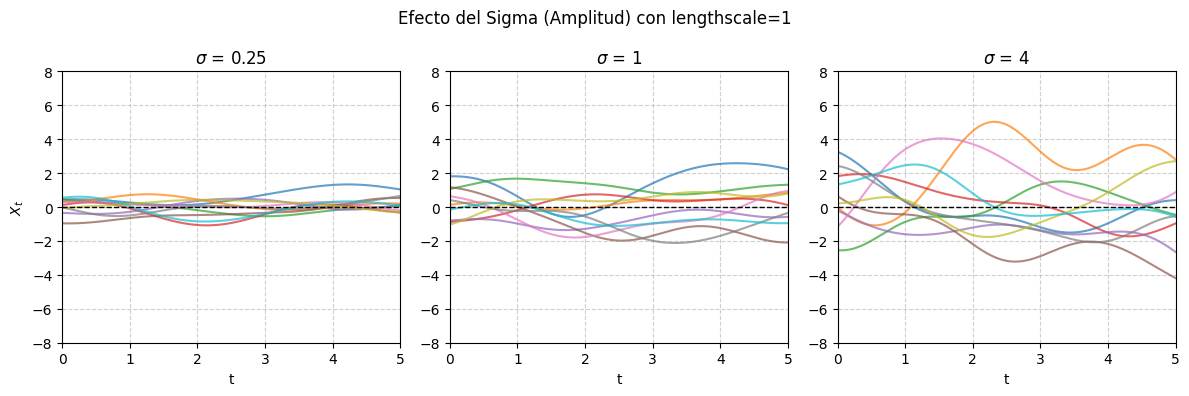

In [67]:
# COMPLETAR (PARA LA DIAPOSITIVA 59)

# eje x
t = np.linspace(0, 5, 500)

# valores de sigma
sigmas=[0.25,1,4]

# figura
fig, axs = plt.subplots(ncols=3, figsize= (12,4))

for i, sigma in enumerate(sigmas):
    y = simular_GP_RBF(t, sigma_sq=sigma, lengthscale=1, num_samples=10)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].axhline(0, color='black', linestyle='--', linewidth=1)
    axs[i].set_title(rf'$\sigma$ = {sigma}')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-8,8)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle('Efecto del Sigma (Amplitud) con lengthscale=1')
plt.tight_layout()
plt.show()



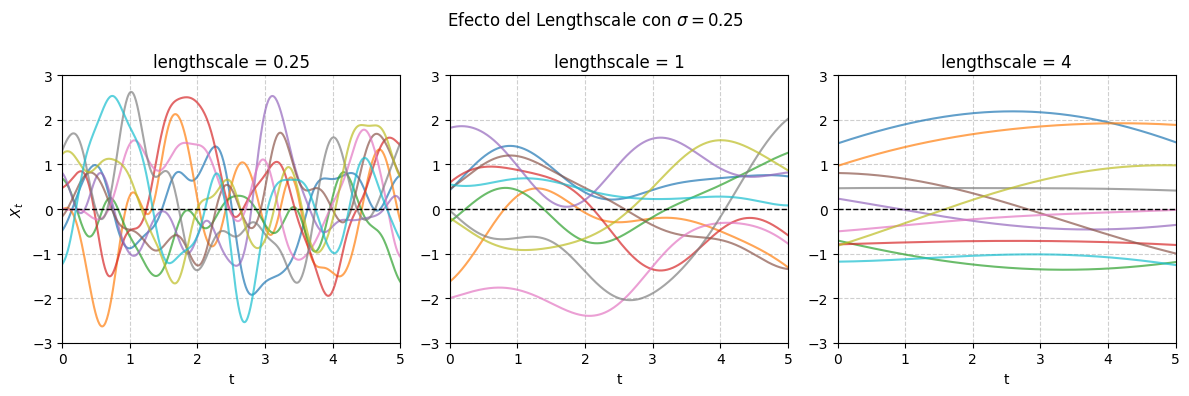

In [73]:
# COMPLETAR (PARA LA DIAPOSITIVA 62)

# eje x
t = np.linspace(0, 5, 500)

# valores de sigma
lengthscales=[0.25,1,4]

# figura
fig, axs = plt.subplots(ncols=3, figsize= (12,4))

for i, l in enumerate(lengthscales):
    y = simular_GP_RBF(t, sigma_sq=1, lengthscale=l, num_samples=10)
    axs[i].plot(t, y.T, alpha=0.7)
    axs[i].axhline(0, color='black', linestyle='--', linewidth=1)
    axs[i].set_title('lengthscale = ' f'{l}')
    axs[i].set_xlabel('t')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].set_xlim(0,5)
    axs[i].set_ylim(-3,3)

axs[0].set_ylabel(r'$X_t$')
fig.suptitle('Efecto del Lengthscale con ' r'$\sigma = 0.25$')
plt.tight_layout()
plt.show()